In [151]:
import pandas as pd

In [153]:
import numpy as np

In [155]:
import yfinance as yf

In [157]:
from scipy.stats import norm

In [159]:
import matplotlib.pyplot as plt

In [161]:
%matplotlib inline

In [163]:
ticker='HON'
data=pd.DataFrame()
for t in ticker:
    ticker_obj=yf.Ticker(ticker)
    data[t]=ticker_obj.history(start='2021-01-01', end='2025-12-31', auto_adjust=False)['Adj Close']
data

,H,O,N
Date,,,
2021-01-04 00:00:00-05:00,175.154236,175.154236,175.154236
2021-01-05 00:00:00-05:00,175.583786,175.583786,175.583786
2021-01-06 00:00:00-05:00,178.784470,178.784470,178.784470
2021-01-07 00:00:00-05:00,179.079315,179.079315,179.079315
2021-01-08 00:00:00-05:00,176.906204,176.906204,176.906204
...,...,...,...
2025-12-23 00:00:00-05:00,193.470917,193.470917,193.470917
2025-12-24 00:00:00-05:00,194.886063,194.886063,194.886063
2025-12-26 00:00:00-05:00,195.321487,195.321487,195.321487


In [164]:
data['return']=(data['H'].pct_change())
data['return']

Date
2021-01-04 00:00:00-05:00         NaN
2021-01-05 00:00:00-05:00    0.002452
2021-01-06 00:00:00-05:00    0.018229
2021-01-07 00:00:00-05:00    0.001649
2021-01-08 00:00:00-05:00   -0.012135
                               ...   
2025-12-23 00:00:00-05:00   -0.002347
2025-12-24 00:00:00-05:00    0.007315
2025-12-26 00:00:00-05:00    0.002234
2025-12-29 00:00:00-05:00   -0.001419
2025-12-30 00:00:00-05:00   -0.003704
Name: return, Length: 1254, dtype: float64

In [165]:
data

,H,O,N,return
Date,,,,
2021-01-04 00:00:00-05:00,175.154236,175.154236,175.154236,NaN
2021-01-05 00:00:00-05:00,175.583786,175.583786,175.583786,0.002452
2021-01-06 00:00:00-05:00,178.784470,178.784470,178.784470,0.018229
2021-01-07 00:00:00-05:00,179.079315,179.079315,179.079315,0.001649
2021-01-08 00:00:00-05:00,176.906204,176.906204,176.906204,-0.012135
...,...,...,...,...
2025-12-23 00:00:00-05:00,193.470917,193.470917,193.470917,-0.002347
2025-12-24 00:00:00-05:00,194.886063,194.886063,194.886063,0.007315
2025-12-26 00:00:00-05:00,195.321487,195.321487,195.321487,0.002234


In [166]:
#parameters for CIR model

# k - mean reverting speed
# ɵ - long term mean
# r0 - initial interest rate
# σ - volatility
# n - number of days
#dt - daily time step assuming 252 trading days in a year

In [171]:
k=7.5
ɵ=0.0549

In [173]:
r0=data['return'].iloc[1]
r0

0.0024524109784658243

In [175]:
σ=data['return'].std()
σ

0.013347816956010146

In [177]:
n=data['return'].count()
n

1253

In [179]:
dt=1/252
dt

0.003968253968253968

In [181]:
#simulating the interest rates for 1253 days 10 times

In [183]:
z=np.random.standard_normal((n,10))
z

array([[-0.35113868,  1.81011787, -1.16329516, ...,  0.30633976,
        -0.7513007 , -2.41066673],
       [ 0.21861598, -0.03721492, -0.78901168, ..., -0.35007652,
         0.87450125, -2.365945  ],
       [ 0.54953906,  0.84645039,  0.79319229, ...,  0.29055786,
        -0.4853542 ,  0.13458673],
       ...,
       [-0.65773278, -0.91642376, -0.76587625, ..., -0.45564947,
        -0.41103738,  0.51393964],
       [ 0.62412976,  0.39193916, -2.04169458, ..., -0.39319767,
        -1.29373483,  1.64495866],
       [ 0.72087041, -0.24044484,  0.46118785, ..., -0.0929136 ,
        -1.11148397, -0.58803245]])

In [185]:
s=np.zeros_like(z)
s

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [187]:
s[0]=data['return'].iloc[1]
s[0]

array([0.00245241, 0.00245241, 0.00245241, 0.00245241, 0.00245241,
       0.00245241, 0.00245241, 0.00245241, 0.00245241, 0.00245241])

In [189]:
for t in range(1,n):
    s[t]=(k*(ɵ-s[t-1])*dt) + (σ*(s[t-1]**0.5)*(dt**0.5)*z[t]) + s[t-1]
s

array([[0.00245241, 0.00245241, 0.00245241, ..., 0.00245241, 0.00245241,
        0.00245241],
       [0.00402245, 0.0040118 , 0.0039805 , ..., 0.00399877, 0.00404977,
        0.00391483],
       [0.00556597, 0.00557141, 0.00553804, ..., 0.00552914, 0.00553719,
        0.00543933],
       ...,
       [0.05424003, 0.05425302, 0.0536903 , ..., 0.05430641, 0.05427602,
        0.0547619 ],
       [0.0543819 , 0.05434903, 0.05332852, ..., 0.05424703, 0.05404116,
        0.05508968],
       [0.05453866, 0.0543183 , 0.05346484, ..., 0.05424827, 0.05384946,
        0.05496799]])

In [191]:
s.shape

(1253, 10)

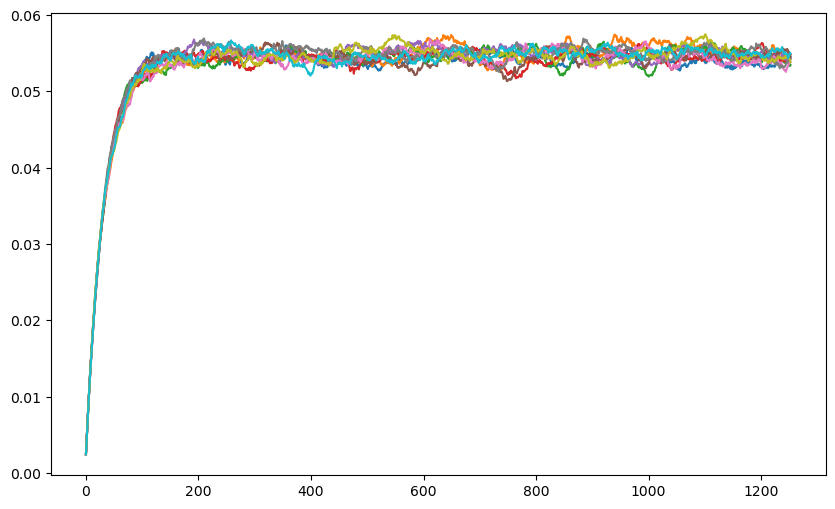

In [201]:
plt.figure(figsize=(10,6))
plt.plot(s[:,:10])
plt.show()